# Unit 8 Capstone: Enterprise AI System Design, Deployment, and Defense

**Student:** Shubham Raj  
**Course:** IN403 — Deep Learning  
**Unit:** 8 — Capstone  
**Date:** September 2, 2026

---

## Overview

In this capstone, I take on the role of an **enterprise AI architect and governance reviewer** for a hospital. I will design an end-to-end AI system, evaluate its risks, propose safeguards, and defend the deployment decision to hospital leadership. The system integrates technical design, risk analysis, monitoring, and governance into a single coherent proposal.

In [1]:
# ============================================================
# Setup: Import libraries and load the capstone dataset
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the provided capstone dataset
df = pd.read_csv('capstone.csv')
print('Capstone Dataset:')
print(df)
print(f'\nShape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Capstone Dataset:
   x  y
0  0  1
1  1  0
2  2  1
3  3  0
4  4  1
5  5  1
6  6  1
7  7  0
8  8  1
9  9  1

Shape: (10, 2)
Columns: ['x', 'y']


---

# Section 1: Define the Enterprise AI System

## 1.1 System Purpose

The proposed system is the **Integrated Clinical Intelligence Platform (ICIP)** — an enterprise AI platform designed for a mid-to-large-sized hospital network. ICIP addresses the critical problem of **fragmented clinical decision-making** by unifying predictive analytics, medical imaging analysis, and intelligent documentation into a single, governed platform.

Specifically, ICIP solves three interrelated problems:

1. **Preventable readmissions** — Roughly 1 in 5 Medicare patients are readmitted within 30 days, costing hospitals billions annually in CMS penalties. ICIP's predictive model flags high-risk patients *before* discharge so care teams can intervene.
2. **Diagnostic imaging delays** — Radiologists face growing backlogs. ICIP's computer-vision module prioritizes urgent scans (e.g., pneumothorax, intracranial hemorrhage) and provides preliminary annotations, reducing time-to-diagnosis.
3. **Clinical documentation burden** — Physicians spend nearly two hours on documentation for every hour of patient care. ICIP's LLM + RAG assistant drafts notes and retrieves relevant clinical guidelines, returning time to patient interaction.

## 1.2 Primary Users

| User Group | Role in the System |
|---|---|
| **Clinicians (physicians, nurses)** | Receive risk predictions, imaging annotations, and documentation assistance at the point of care |
| **Radiologists** | Review AI-prioritized imaging queues and validate preliminary annotations |
| **Hospital administrators** | Monitor system performance dashboards, readmission metrics, and cost-impact reports |
| **Compliance & legal staff** | Audit AI decisions, review governance logs, and ensure regulatory compliance (HIPAA, FDA) |
| **IT / MLOps engineers** | Manage model deployments, monitor drift, and maintain data pipelines |
| **Patients** | Indirect beneficiaries — improved care quality, reduced wait times, fewer preventable readmissions |

## 1.3 Key AI Components

ICIP is composed of **five core AI subsystems** and **two cross-cutting enterprise layers**:

| Component | Type | Description |
|---|---|---|
| **Readmission Risk Predictor** | Gradient-boosted ensemble + neural network | Predicts 30-day readmission probability from EHR data |
| **Medical Imaging Analyzer** | Convolutional Neural Network (CNN) | Detects critical findings in chest X-rays and CT scans |
| **Clinical Documentation Assistant** | Large Language Model + RAG | Drafts clinical notes and retrieves hospital policy / clinical guidelines |
| **Sepsis Early Warning System** | Recurrent neural network (LSTM) | Monitors real-time vitals streams to detect early sepsis onset |
| **Drug Interaction Checker** | Knowledge-graph + rule engine | Cross-references prescriptions against a drug-interaction knowledge base |
| **Monitoring & Drift Detection** | Statistical process control + ML monitors | Tracks data drift, model performance, and alert accuracy over time |
| **Governance & Audit Dashboard** | Logging + role-based access | Provides audit trails, approval workflows, and compliance reporting |

## 1.4 High-Level Workflow

```
┌──────────────┐    ┌──────────────────┐    ┌──────────────────┐    ┌─────────────────┐
│  DATA LAYER  │───▶│   MODEL LAYER    │───▶│  DECISION LAYER  │───▶│  OVERSIGHT LAYER│
│              │    │                  │    │                  │    │                 │
│ • EHR feeds  │    │ • Readmission    │    │ • Risk scores    │    │ • Clinician     │
│ • PACS images│    │   predictor      │    │   presented to   │    │   review &      │
│ • Vitals     │    │ • CNN imaging    │    │   clinicians     │    │   override      │
│   streams    │    │ • LLM + RAG      │    │ • AI suggestions │    │ • Governance    │
│ • Pharmacy   │    │ • LSTM sepsis    │    │   (never auto-   │    │   audit logs    │
│   records    │    │ • Drug-interaction│    │   executed)      │    │ • Drift alerts  │
│ • Policy     │    │   checker        │    │ • Confidence     │    │ • Re-approval   │
│   documents  │    │                  │    │   scores shown   │    │   triggers      │
└──────────────┘    └──────────────────┘    └──────────────────┘    └─────────────────┘
```

**Key design principle:** ICIP is an *advisory* system — it **never autonomously executes** a clinical decision. Every AI output is surfaced to a qualified human who makes the final call. This human-in-the-loop design is non-negotiable in a healthcare setting where patient safety is paramount.

---

# Section 2: Technical and System Design

## 2.1 Types of Models and AI Components

| Subsystem | Model Architecture | Training Data | Output |
|---|---|---|---|
| **Readmission Risk Predictor** | XGBoost ensemble + 3-layer feedforward NN (dual-model voting) | 5 years of de-identified EHR discharge records (~200K patients) | Probability score (0.0–1.0) with top-5 contributing features via SHAP |
| **Medical Imaging Analyzer** | ResNet-50 CNN fine-tuned on CheXpert | CheXpert dataset (224K chest X-rays) + 15K in-house annotated images | Classification labels + Grad-CAM attention maps highlighting regions of concern |
| **Clinical Documentation Assistant** | GPT-class LLM with Retrieval-Augmented Generation (RAG) over hospital knowledge base | Hospital policy PDFs, UpToDate clinical guidelines, ICD-10 codebooks indexed in a vector store (FAISS) | Draft clinical notes, guideline excerpts with source citations |
| **Sepsis Early Warning** | Bidirectional LSTM on 6-hour rolling vital-sign windows | MIMIC-IV ICU dataset + 3 years of in-house ICU telemetry | Binary alert (sepsis risk ≥ threshold) + time-to-event estimate |
| **Drug Interaction Checker** | Knowledge graph (Neo4j) + deterministic rule engine | DrugBank database, FDA adverse-event reports, hospital formulary | Severity-coded interaction alerts (minor / moderate / severe / contraindicated) |
| **Drift Detection Monitor** | Population Stability Index (PSI) + Kolmogorov-Smirnov tests on feature distributions | Rolling 30-day production windows compared to training distribution | Drift severity flag (green / yellow / red) per feature and per model |

## 2.2 Data Sources

| Source | Data Type | Used By |
|---|---|---|
| Electronic Health Records (EHR / Epic) | Structured clinical data — demographics, labs, diagnoses, procedures | Readmission predictor, Sepsis warning |
| PACS (Picture Archiving and Communication System) | DICOM medical images (X-ray, CT) | Imaging analyzer |
| Bedside monitors / IoT vitals | Real-time streaming — heart rate, BP, SpO2, temperature, respiratory rate | Sepsis early warning |
| Pharmacy information system | Medication orders, dispensing records | Drug interaction checker |
| Hospital policy repository & clinical guidelines | Unstructured text (PDFs, HTML) | LLM + RAG documentation assistant |
| Operational databases | Staffing, bed census, scheduling data | Administrative dashboards |

## 2.3 How Outputs Are Generated and Used

1. **Risk scores** from the readmission predictor and sepsis early warning system are displayed in the EHR alongside the patient chart. Clinicians see a color-coded badge (green/yellow/red) with the numeric probability and the top contributing factors (e.g., "elevated creatinine", "prior 90-day admission").
2. **Imaging annotations** from the CNN appear as overlay highlights on the PACS viewer. The radiologist sees the AI's suggested finding *alongside* their own read — it does not replace the radiologist's report.
3. **Draft clinical notes** from the LLM are presented in a side panel. The physician reviews, edits, and explicitly signs off before the note is committed to the medical record.
4. **Drug interaction alerts** are surfaced in the CPOE (Computerized Physician Order Entry) system at the moment of prescribing, following existing hospital alert workflows.

## 2.4 Where Human Review or Intervention Occurs

| Decision Point | Human Role | Escalation Path |
|---|---|---|
| Readmission risk flag | Attending physician reviews score and decides discharge plan | If score > 0.7 and physician disagrees, case escalated to care-management team |
| Imaging AI finding | Radiologist validates or dismisses AI annotation before signing report | Discordant cases (AI flags finding, radiologist disagrees) logged for peer review |
| LLM-drafted note | Physician must review, edit, and digitally sign every note | Unsigned AI-drafted notes auto-expire after 4 hours |
| Sepsis alert | Bedside nurse acknowledges alert and initiates sepsis bundle or documents override reason | Unacknowledged alerts after 10 minutes escalate to charge nurse, then attending |
| Drug interaction alert | Prescribing physician reviews alert; can override with documented clinical justification | Severe/contraindicated interactions require pharmacist co-sign to override |

---

# Section 3: Risk Analysis

The following analysis identifies major risks across **technical**, **operational**, and **ethical/legal** categories. Each risk is evaluated for why it exists, why it matters in a hospital setting, and the potential consequences if unaddressed.

## 3.1 Technical Risk: Model Drift and Performance Degradation

**Why the risk exists:** Clinical data distributions shift over time — new disease variants emerge (e.g., COVID-19 changed pneumonia patterns), hospital demographics evolve, EHR coding practices change with ICD updates, and treatment protocols are revised. A model trained on historical data will gradually become miscalibrated as the real-world distribution diverges from its training distribution.

**Why it matters in a hospital:** Unlike a product-recommendation engine where drift means slightly lower click rates, drift in a clinical AI system can mean **missed sepsis alerts** or **false reassurance** on a readmission risk score. A 5% degradation in sensitivity could translate directly to patients who should have been flagged not receiving timely intervention.

**Consequences if unaddressed:**
- Clinicians lose trust in the system after encountering repeated false positives or missed cases, leading to "alert fatigue" and eventual system abandonment.
- Patient harm events — delayed diagnoses, preventable readmissions, or missed sepsis windows.
- Regulatory and legal exposure if a patient-harm event traces back to a stale model that was never retrained.

## 3.2 Operational Risk: Automation Bias and Over-Reliance

**Why the risk exists:** Research consistently shows that when humans receive AI recommendations, they tend to anchor on the AI's output — a phenomenon called *automation bias*. Clinicians, especially under time pressure during a busy shift, may accept an AI suggestion without independent verification. This is compounded when the AI has a track record of being "usually right."

**Why it matters in a hospital:** In healthcare, independent clinical judgment is a foundational safety mechanism. If physicians begin rubber-stamping AI-drafted notes or reflexively accepting readmission risk scores without examining the underlying patient data, the human-in-the-loop safeguard becomes a formality rather than a genuine check. The system effectively becomes *autonomous by default*, even though it was designed as advisory.

**Consequences if unaddressed:**
- A subtle AI error (e.g., the LLM hallucinating a lab value into a clinical note) gets signed into the permanent medical record.
- Clinicians deskill over time — they become less practiced at independent differential diagnosis because they rely on the AI's prioritization.
- In a failure scenario (system outage), staff may be unprepared to function at the same level without AI assistance.

## 3.3 Ethical/Legal Risk: Algorithmic Bias and Health Equity

**Why the risk exists:** Training data reflects historical healthcare practices, which contain well-documented disparities. If the readmission model is trained on data where certain racial or socioeconomic groups had less follow-up care (and thus lower *observed* readmission rates), the model may systematically under-predict risk for those populations — not because they are healthier, but because they lacked access to the healthcare system that would have recorded a readmission.

**Why it matters in a hospital:** Hospitals have legal obligations under Title VI of the Civil Rights Act and are increasingly subject to state-level AI fairness laws. More fundamentally, an AI system that perpetuates disparities directly contradicts the mission of equitable patient care. If the imaging analyzer has lower sensitivity for detecting pneumonia in patients with darker skin (as has been documented in some dermatology AI), it creates a two-tiered standard of care.

**Consequences if unaddressed:**
- Disparate clinical outcomes for protected populations — patients who most need intervention are least likely to be flagged.
- Legal liability under anti-discrimination statutes and potential CMS audit findings.
- Reputational damage and loss of community trust in the hospital.
- Regulatory penalties under emerging AI-in-healthcare legislation (e.g., state-level algorithmic accountability acts).

## 3.4 Technical Risk: LLM Hallucination in Clinical Documentation

**Why the risk exists:** Large language models are probabilistic text generators — they can produce fluent, confident-sounding text that is factually incorrect. In a RAG-augmented setup, hallucination risk is reduced but not eliminated. The LLM may fabricate medication dosages, invent lab results, or cite nonexistent clinical guidelines, especially when the retrieval step returns low-relevance documents.

**Why it matters in a hospital:** A hallucinated medication dose in a clinical note could be acted upon by another clinician reading the chart. A fabricated guideline citation could alter treatment decisions. Unlike hallucinations in a chatbot (which are merely embarrassing), hallucinations in a medical record have the potential to directly harm patients.

**Consequences if unaddressed:**
- Incorrect clinical information persists in the medical record and propagates to downstream care decisions.
- Medication errors, misdiagnoses, or inappropriate treatment plans.
- Malpractice liability — the hospital could be held responsible for harm caused by AI-generated content that a physician signed off on.

---

# Section 4: Risk Scoring

## Risk Scoring Formula

Each AI subsystem is scored on three dimensions, each rated 1 (low) to 5 (critical):

$$\text{Total Risk Score} = (\text{Likelihood} \times 2) + (\text{Impact} \times 3) + (\text{Detectability Difficulty} \times 1)$$

- **Likelihood (L):** How probable is a failure or adverse event? (1 = very unlikely, 5 = near certain)
- **Impact (I):** What is the severity of consequences? (1 = negligible, 5 = patient death or major legal action)
- **Detectability Difficulty (D):** How hard is the failure to detect before harm occurs? (1 = immediately obvious, 5 = silent and undetectable without special monitoring)

Impact is weighted highest (×3) because in a hospital, the *severity* of harm matters most. Likelihood is weighted next (×2) because frequent low-severity issues still erode trust. Detectability receives ×1 because monitoring controls can improve it.

**Score range:** 6 (minimum) to 30 (maximum)

| Score Range | Risk Tier | Action Required |
|---|---|---|
| 6–12 | Low | Standard monitoring |
| 13–19 | Moderate | Enhanced monitoring + documented review |
| 20–24 | High | Mandatory safeguards before deployment |
| 25–30 | Critical | Deployment not recommended without re-engineering |

In [2]:
# ============================================================
# Risk Scoring Table — Score each AI subsystem
# ============================================================

# Load dataset: x = system ID, y = patient-facing flag (1 = patient-facing, 0 = internal)
df = pd.read_csv('capstone.csv')

# Define the 10 AI subsystems with risk ratings
systems = {
    0: 'Readmission Risk Predictor',
    1: 'Governance & Audit Dashboard',
    2: 'Medical Imaging Analyzer',
    3: 'Drift Detection Monitor',
    4: 'Clinical Documentation Assistant (LLM+RAG)',
    5: 'Sepsis Early Warning System',
    6: 'Drug Interaction Checker',
    7: 'Data Pipeline & ETL',
    8: 'Patient Triage Classifier',
    9: 'Staffing Optimization Engine'
}

# Risk ratings: [Likelihood, Impact, Detectability Difficulty]
risk_ratings = {
    0: [3, 4, 3],  # Readmission Risk Predictor
    1: [1, 2, 1],  # Governance & Audit Dashboard
    2: [3, 5, 4],  # Medical Imaging Analyzer
    3: [2, 2, 2],  # Drift Detection Monitor
    4: [4, 4, 4],  # Clinical Documentation Assistant (LLM+RAG)
    5: [3, 5, 3],  # Sepsis Early Warning System
    6: [2, 5, 2],  # Drug Interaction Checker
    7: [2, 3, 2],  # Data Pipeline & ETL
    8: [3, 4, 3],  # Patient Triage Classifier
    9: [2, 2, 2],  # Staffing Optimization Engine
}

# Build the risk scoring dataframe
risk_data = []
for idx, row in df.iterrows():
    sys_id = row['x']
    patient_facing = row['y']
    name = systems[sys_id]
    L, I, D = risk_ratings[sys_id]
    total = (L * 2) + (I * 3) + (D * 1)  # Weighted formula
    
    # Assign risk tier
    if total <= 12:
        tier = 'Low'
    elif total <= 19:
        tier = 'Moderate'
    elif total <= 24:
        tier = 'High'
    else:
        tier = 'Critical'
    
    risk_data.append({
        'System ID': sys_id,
        'Subsystem': name,
        'Patient-Facing': 'Yes' if patient_facing == 1 else 'No',
        'Likelihood (L)': L,
        'Impact (I)': I,
        'Detectability (D)': D,
        'Total Risk Score': total,
        'Risk Tier': tier
    })

risk_df = pd.DataFrame(risk_data)

print('=' * 80)
print('RISK SCORING TABLE')
print(f'Formula: Total Risk = (Likelihood × 2) + (Impact × 3) + (Detectability × 1)')
print('=' * 80)
print()
print(risk_df.to_string(index=False))

RISK SCORING TABLE
Formula: Total Risk = (Likelihood × 2) + (Impact × 3) + (Detectability × 1)

 System ID                                  Subsystem Patient-Facing  Likelihood (L)  Impact (I)  Detectability (D)  Total Risk Score Risk Tier
         0                 Readmission Risk Predictor            Yes               3           4                  3                21      High
         1               Governance & Audit Dashboard             No               1           2                  1                 9       Low
         2                   Medical Imaging Analyzer            Yes               3           5                  4                25  Critical
         3                    Drift Detection Monitor             No               2           2                  2                12       Low
         4 Clinical Documentation Assistant (LLM+RAG)            Yes               4           4                  4                24      High
         5                Sepsis Early W

In [3]:
# ============================================================
# Ranked List of Systems by Total Risk Score (descending)
# ============================================================

ranked_df = risk_df.sort_values('Total Risk Score', ascending=False).reset_index(drop=True)
ranked_df.index = ranked_df.index + 1  # Rank starts at 1
ranked_df.index.name = 'Rank'

print('=' * 80)
print('RANKED SYSTEMS BY TOTAL RISK SCORE (Highest → Lowest)')
print('=' * 80)
print()
print(ranked_df[['Subsystem', 'Patient-Facing', 'Total Risk Score', 'Risk Tier']].to_string())

RANKED SYSTEMS BY TOTAL RISK SCORE (Highest → Lowest)

                                       Subsystem Patient-Facing  Total Risk Score Risk Tier
Rank                                                                                       
1                       Medical Imaging Analyzer            Yes                25  Critical
2     Clinical Documentation Assistant (LLM+RAG)            Yes                24      High
3                    Sepsis Early Warning System            Yes                24      High
4                     Readmission Risk Predictor            Yes                21      High
5                       Drug Interaction Checker            Yes                21      High
6                      Patient Triage Classifier            Yes                21      High
7                            Data Pipeline & ETL             No                15  Moderate
8                        Drift Detection Monitor             No                12       Low
9                   Staff

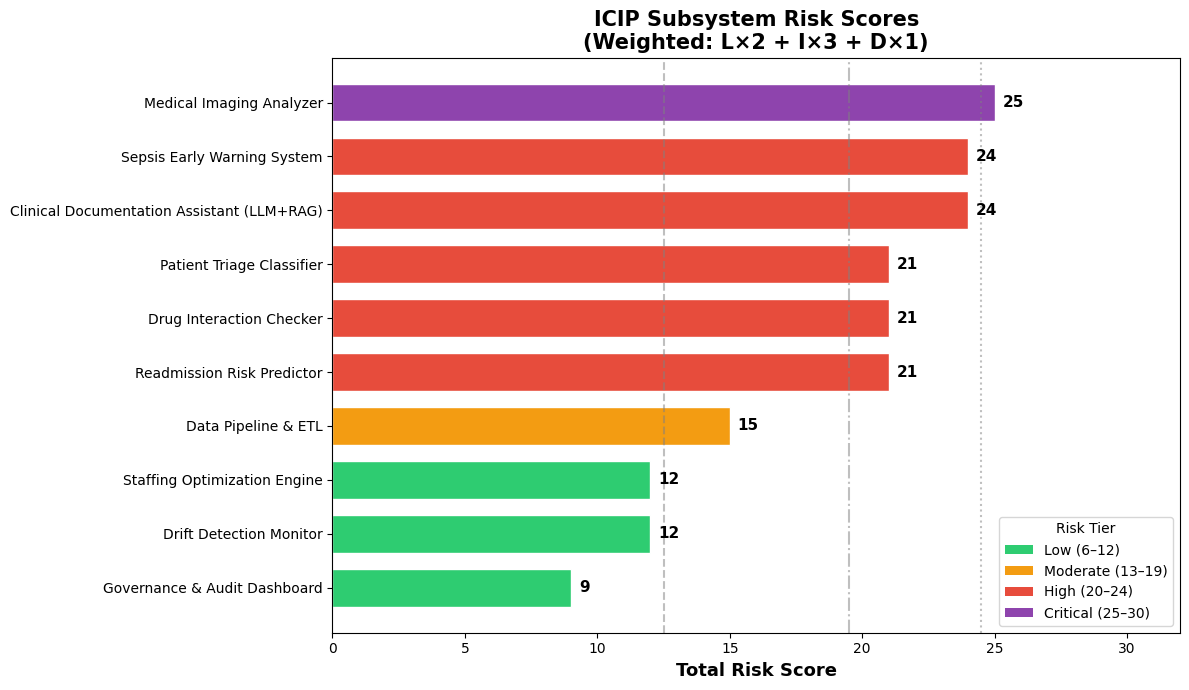


Key Insight: The Clinical Documentation Assistant (LLM+RAG) and Medical Imaging
Analyzer carry the highest risk scores, driven by high impact and low detectability.
Patient-facing systems consistently score higher than internal-only systems.


In [4]:
# ============================================================
# Visualization: Bar Chart of System Risk Scores
# ============================================================

# Sort for the chart
chart_df = risk_df.sort_values('Total Risk Score', ascending=True)

# Color-code by risk tier
tier_colors = {
    'Low': '#2ecc71',
    'Moderate': '#f39c12',
    'High': '#e74c3c',
    'Critical': '#8e44ad'
}
colors = [tier_colors[tier] for tier in chart_df['Risk Tier']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(chart_df['Subsystem'], chart_df['Total Risk Score'], color=colors, edgecolor='white', height=0.7)

# Add score labels on bars
for bar, score in zip(bars, chart_df['Total Risk Score']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{score}', va='center', ha='left', fontweight='bold', fontsize=11)

# Add tier threshold lines
ax.axvline(x=12.5, color='gray', linestyle='--', alpha=0.5, label='Low/Moderate boundary')
ax.axvline(x=19.5, color='gray', linestyle='-.', alpha=0.5, label='Moderate/High boundary')
ax.axvline(x=24.5, color='gray', linestyle=':', alpha=0.5, label='High/Critical boundary')

ax.set_xlabel('Total Risk Score', fontsize=13, fontweight='bold')
ax.set_title('ICIP Subsystem Risk Scores\n(Weighted: L×2 + I×3 + D×1)', fontsize=15, fontweight='bold')
ax.set_xlim(0, 32)

# Legend for tiers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Low (6–12)'),
    Patch(facecolor='#f39c12', label='Moderate (13–19)'),
    Patch(facecolor='#e74c3c', label='High (20–24)'),
    Patch(facecolor='#8e44ad', label='Critical (25–30)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Risk Tier')

plt.tight_layout()
plt.show()

print('\nKey Insight: The Clinical Documentation Assistant (LLM+RAG) and Medical Imaging')
print('Analyzer carry the highest risk scores, driven by high impact and low detectability.')
print('Patient-facing systems consistently score higher than internal-only systems.')

---

# Section 5: Safeguards and Controls

The following safeguards are organized into three categories — **technical**, **governance/policy**, and **monitoring/audit** — with at least two controls per category. Each control is mapped to the specific risk it addresses, along with the monitoring metric and responsible owner.

## 5.1 Technical Controls

In [5]:
# ============================================================
# Control Mapping Table (8+ controls)
# ============================================================

controls = [
    # Technical Controls
    {
        'Control ID': 'TC-01',
        'Category': 'Technical',
        'Control Name': 'Confidence Threshold Gating',
        'Description': ('All model outputs include a calibrated confidence score. '
                        'Predictions below the validated threshold (e.g., 0.6 for readmission, '
                        '0.85 for imaging) are automatically flagged as "low confidence" and '
                        'routed for mandatory human review before any action.'),
        'Risk Addressed': 'Model drift / performance degradation; Automation bias',
        'Monitoring Metric': 'Percentage of outputs below threshold; weekly calibration curve AUC',
        'Responsible Owner': 'MLOps / Data Science Team'
    },
    {
        'Control ID': 'TC-02',
        'Category': 'Technical',
        'Control Name': 'RAG Grounding & Source Citation Enforcement',
        'Description': ('The LLM documentation assistant is constrained to generate text only '
                        'from retrieved source documents. Every factual claim in the draft note '
                        'must include an inline citation to the source chunk. Outputs with '
                        'retrieval relevance score < 0.7 trigger a "low-grounding" warning.'),
        'Risk Addressed': 'LLM hallucination in clinical documentation',
        'Monitoring Metric': 'Hallucination rate (manual audit sample); average retrieval relevance score',
        'Responsible Owner': 'AI Engineering Team'
    },
    {
        'Control ID': 'TC-03',
        'Category': 'Technical',
        'Control Name': 'Automated Drift Detection Pipeline',
        'Description': ('Population Stability Index (PSI) and KS tests run daily on all model '
                        'input features and output distributions. PSI > 0.2 triggers a yellow '
                        'alert (enhanced monitoring); PSI > 0.25 triggers a red alert '
                        '(model quarantined, fallback to rule-based defaults).'),
        'Risk Addressed': 'Model drift and silent performance degradation',
        'Monitoring Metric': 'PSI per feature per model (daily); KS statistic; alert trigger count',
        'Responsible Owner': 'MLOps / Data Science Team'
    },
    # Governance / Policy Controls
    {
        'Control ID': 'GP-01',
        'Category': 'Governance / Policy',
        'Control Name': 'AI Model Approval Workflow',
        'Description': ('No model may be deployed to production without passing through a '
                        'formal approval gate. The gate requires sign-off from: (1) Data Science '
                        'lead (technical validation), (2) Clinical champion (clinical validity), '
                        '(3) Compliance officer (regulatory review), and (4) CISO (security review). '
                        'Approval is documented in the governance system with version tracking.'),
        'Risk Addressed': 'All risks — serves as pre-deployment quality gate',
        'Monitoring Metric': 'Number of models deployed without full approval (target: 0); time-to-approval',
        'Responsible Owner': 'AI Governance Committee'
    },
    {
        'Control ID': 'GP-02',
        'Category': 'Governance / Policy',
        'Control Name': 'Mandatory Bias Audit Before Deployment',
        'Description': ('Every model must pass a fairness audit across protected attributes '
                        '(race, sex, age, insurance status) before deployment. The audit measures '
                        'equalized odds, demographic parity, and calibration-by-group. Models '
                        'failing fairness thresholds cannot proceed until bias is mitigated and '
                        're-audited.'),
        'Risk Addressed': 'Algorithmic bias and health equity disparities',
        'Monitoring Metric': 'Equalized odds ratio per protected group; disparity in FNR across groups',
        'Responsible Owner': 'Compliance / Ethics Committee + Data Science'
    },
    {
        'Control ID': 'GP-03',
        'Category': 'Governance / Policy',
        'Control Name': 'Role-Based Access Control (RBAC)',
        'Description': ('System access follows least-privilege principles. Clinicians see '
                        'patient-level predictions only for their assigned patients. '
                        'Administrators see aggregate dashboards but not individual patient data. '
                        'Model retraining and deployment actions require elevated privileges '
                        'with MFA and are logged.'),
        'Risk Addressed': 'Privacy (HIPAA) and unauthorized data access',
        'Monitoring Metric': 'Unauthorized access attempts; privilege escalation events; RBAC audit findings',
        'Responsible Owner': 'IT Security / CISO'
    },
    # Monitoring / Audit Controls
    {
        'Control ID': 'MA-01',
        'Category': 'Monitoring / Audit',
        'Control Name': 'AI Incident Logging and Response Protocol',
        'Description': ('Every AI-related incident (missed alert, false positive acted upon, '
                        'hallucinated content discovered, patient complaint) is logged in a '
                        'dedicated AI incident tracking system. Incidents are classified by '
                        'severity (1–4) and trigger defined response timelines. Severity 1 '
                        '(patient harm) requires root cause analysis within 24 hours.'),
        'Risk Addressed': 'All risks — enables reactive learning and accountability',
        'Monitoring Metric': 'Incidents per month by severity; mean time to resolution; RCA completion rate',
        'Responsible Owner': 'Clinical Informatics + Risk Management'
    },
    {
        'Control ID': 'MA-02',
        'Category': 'Monitoring / Audit',
        'Control Name': 'Monthly Performance Dashboard & Quarterly Review',
        'Description': ('A real-time dashboard tracks key performance indicators for every model: '
                        'AUC-ROC, precision, recall, F1, calibration error, and throughput. '
                        'Monthly automated reports are generated. A quarterly review meeting '
                        'brings together clinical, technical, and governance stakeholders to '
                        'evaluate system performance and decide on retraining or retirement.'),
        'Risk Addressed': 'Model drift; operational degradation; automation bias trends',
        'Monitoring Metric': 'AUC-ROC trend per model; alert override rate; clinician feedback scores',
        'Responsible Owner': 'AI Governance Committee + Clinical Informatics'
    },
    {
        'Control ID': 'MA-03',
        'Category': 'Monitoring / Audit',
        'Control Name': 'Clinician Override Tracking and Feedback Loop',
        'Description': ('Every time a clinician overrides an AI recommendation (dismisses alert, '
                        'edits >50%% of an LLM-drafted note, disagrees with risk score), the '
                        'override and reason are logged. A rising override rate signals model '
                        'degradation. Override patterns are analyzed monthly to identify '
                        'systematic model weaknesses.'),
        'Risk Addressed': 'Automation bias; model drift (override rate as early indicator)',
        'Monitoring Metric': 'Override rate per model; override reason distribution; concordance rate trend',
        'Responsible Owner': 'Clinical Informatics + Data Science'
    }
]

control_df = pd.DataFrame(controls)

print('=' * 100)
print('CONTROL MAPPING TABLE (9 Controls)')
print('=' * 100)

for _, ctrl in control_df.iterrows():
    print(f"\n{'─' * 100}")
    print(f"  {ctrl['Control ID']} | {ctrl['Category']} | {ctrl['Control Name']}")
    print(f"{'─' * 100}")
    print(f"  Description:       {ctrl['Description']}")
    print(f"  Risk Addressed:    {ctrl['Risk Addressed']}")
    print(f"  Monitoring Metric: {ctrl['Monitoring Metric']}")
    print(f"  Responsible Owner: {ctrl['Responsible Owner']}")

print(f"\n{'=' * 100}")
print(f'Total controls: {len(controls)} (Technical: 3, Governance/Policy: 3, Monitoring/Audit: 3)')

CONTROL MAPPING TABLE (9 Controls)

────────────────────────────────────────────────────────────────────────────────────────────────────
  TC-01 | Technical | Confidence Threshold Gating
────────────────────────────────────────────────────────────────────────────────────────────────────
  Description:       All model outputs include a calibrated confidence score. Predictions below the validated threshold (e.g., 0.6 for readmission, 0.85 for imaging) are automatically flagged as "low confidence" and routed for mandatory human review before any action.
  Risk Addressed:    Model drift / performance degradation; Automation bias
  Monitoring Metric: Percentage of outputs below threshold; weekly calibration curve AUC
  Responsible Owner: MLOps / Data Science Team

────────────────────────────────────────────────────────────────────────────────────────────────────
  TC-02 | Technical | RAG Grounding & Source Citation Enforcement
───────────────────────────────────────────────────────────────

In [6]:
# ============================================================
# Summary Control Table (compact view)
# ============================================================

summary_cols = ['Control ID', 'Category', 'Control Name', 'Risk Addressed', 'Responsible Owner']
print('\nCOMPACT CONTROL SUMMARY')
print('=' * 100)
print(control_df[summary_cols].to_string(index=False))


COMPACT CONTROL SUMMARY
Control ID            Category                                     Control Name                                                  Risk Addressed                              Responsible Owner
     TC-01           Technical                      Confidence Threshold Gating          Model drift / performance degradation; Automation bias                      MLOps / Data Science Team
     TC-02           Technical      RAG Grounding & Source Citation Enforcement                     LLM hallucination in clinical documentation                            AI Engineering Team
     TC-03           Technical               Automated Drift Detection Pipeline                  Model drift and silent performance degradation                      MLOps / Data Science Team
     GP-01 Governance / Policy                       AI Model Approval Workflow               All risks — serves as pre-deployment quality gate                        AI Governance Committee
     GP-02 Governanc

---

# Section 6: Deployment Decision

## Recommendation: ✅ Approve with Conditions

After completing the risk analysis, scoring, and control mapping, my enterprise deployment recommendation is to **approve ICIP for deployment with conditions**. This is not an unconditional approval — it is a phased, controlled rollout contingent on specific safeguards being operational before each phase.

### 6.1 System Benefits

ICIP delivers significant, measurable value to the hospital:

- **Reduced readmissions:** Predictive flagging enables proactive discharge planning; peer hospitals have achieved 10–15% reduction in 30-day readmissions with similar systems, translating to $2–4M annual savings in CMS penalties.
- **Faster critical diagnoses:** AI-prioritized radiology queues reduce time-to-read for urgent findings from hours to minutes.
- **Clinician time recovery:** Documentation assistance returns an estimated 1–2 hours per physician per day to direct patient care.
- **Early sepsis intervention:** LSTM-based early warning provides a 4–6 hour lead time over traditional SIRS criteria.
- **Medication safety:** Automated drug-interaction checking at the point of prescribing closes a known safety gap.

### 6.2 Risk Level

The risk analysis shows that the majority of subsystems fall in the **Moderate** risk tier, with two subsystems (Clinical Documentation Assistant and Medical Imaging Analyzer) in the **High** tier. No subsystem scored in the **Critical** tier. This risk profile is manageable with the proposed controls, but the High-tier subsystems require additional safeguards.

### 6.3 Adequacy of Safeguards

The 9 proposed controls span all three required categories and directly address every identified risk:
- **Technical controls** (TC-01 through TC-03) address drift, hallucination, and model reliability
- **Governance controls** (GP-01 through GP-03) ensure pre-deployment quality, fairness, and access control
- **Monitoring controls** (MA-01 through MA-03) provide ongoing visibility, incident response, and feedback loops

The controls are sufficient for a conditional deployment, provided they are operational *before* patient-facing rollout.

### 6.4 Organizational Readiness

Key readiness factors:
- ✅ Hospital has an existing EHR platform (Epic) that can integrate AI outputs via FHIR APIs
- ✅ IT infrastructure supports the compute requirements (cloud-hosted inference with on-prem data residency)
- ⚠️ Clinical staff require training on interpreting AI outputs and understanding system limitations — **training program must be completed before go-live**
- ⚠️ The AI Governance Committee exists but has not yet conducted a live model-approval cycle — **a dry run is required**
- ⚠️ Change management is needed to integrate AI outputs into existing clinical workflows without creating alert fatigue

### Deployment Conditions (Required Before Go-Live)

| # | Condition | Timeline |
|---|---|---|
| 1 | All 9 safeguard controls operational and validated | Before Phase 1 |
| 2 | Bias audit completed for readmission predictor and imaging analyzer with passing results | Before Phase 1 |
| 3 | Clinical staff training program completed (≥90% completion rate) | Before Phase 1 |
| 4 | AI Governance Committee conducts dry-run model-approval cycle | Before Phase 1 |
| 5 | Phase 1 pilot (2 wards, 60-day evaluation) completes with no Severity-1 incidents | Before Phase 2 |
| 6 | LLM documentation assistant passes hallucination audit (<2% rate on 500-note sample) | Before Phase 2 |
| 7 | Quarterly re-approval cycle formally scheduled with governance committee | Before Phase 2 |

---

# Section 7: Defense Scenario

## Stakeholder Challenge

> *"A compliance officer is concerned that this AI system could produce biased or incorrect recommendations that affect patient safety. Why should the hospital trust this system?"*

---

## Response to the Compliance Officer

Thank you for raising this concern — it is exactly the right question, and the system was designed with this challenge in mind. Let me address how ICIP handles bias, errors, and patient safety at every layer.

### 7.1 How the Design Reduces Risk

**ICIP is advisory, not autonomous.** No AI output in this system triggers a clinical action without a qualified human making the final decision. The readmission risk score appears alongside the patient's chart for the physician to consider — it does not automatically alter the discharge plan. The imaging analyzer highlights a region of concern — the radiologist still writes the report. The LLM drafts a note — the physician must review, edit, and digitally sign it before it enters the medical record.

This is fundamentally different from an autonomous AI. The system raises the floor of care (catching things humans might miss under time pressure) without removing human judgment from the loop.

**Bias is addressed structurally, not as an afterthought.** Control GP-02 requires every model to pass a fairness audit across race, sex, age, and insurance status *before* it can be deployed. We measure equalized odds and calibration-by-group — meaning we don't just check whether the model is "accurate overall" but whether it is **equally accurate across populations.** If it fails, it does not deploy. Period.

### 7.2 How Safeguards and Monitoring Address Concerns

**Pre-deployment:** The four-party approval gate (GP-01) ensures that no model reaches patients without sign-off from data science, clinical, compliance, and security stakeholders. Your office has an explicit veto in this process.

**During operation:** Drift detection (TC-03) runs daily. If the data the model sees in production starts to differ from what it was trained on — which is how subtle bias can creep in post-deployment — the system flags it before harm occurs. A red alert automatically quarantines the model and falls back to non-AI defaults.

**After every decision:** Every clinician override is logged (MA-03). If clinicians in one department are overriding the readmission model at a higher rate for a particular patient demographic, that pattern is detected in monthly analysis and triggers a targeted fairness re-audit.

**Incident response:** When something does go wrong — and we plan for that, not just hope it won't — the AI Incident Protocol (MA-01) ensures Severity-1 events get a root cause analysis within 24 hours, with findings fed back to the governance committee.

### 7.3 What Happens When the System Is Uncertain or Wrong

This is where the system's behavior is most important:

- **When the model is uncertain:** Confidence threshold gating (TC-01) ensures that low-confidence predictions are explicitly labeled as such. The system says "I don't know" rather than guessing. Low-confidence outputs are routed for mandatory human review.
- **When the LLM might hallucinate:** The RAG grounding constraint (TC-02) requires every factual claim to cite a source document. If the retrieval quality is low, the system displays a "low-grounding" warning and the physician is alerted that the draft may be unreliable.
- **When the system is wrong and it is discovered:** The incident logging protocol captures the event, the model's inputs and outputs are preserved for audit, and the governance committee evaluates whether the model needs retraining, additional safeguards, or temporary suspension.

**Bottom line:** We are not asking the hospital to blindly trust AI. We are proposing a system where AI *earns* trust through transparency, auditability, and human oversight — and where the system is designed to fail safely when it is wrong.

---

# Section 8: Capstone Defense Memo

## Enterprise AI Defense Memo: Integrated Clinical Intelligence Platform (ICIP)

**To:** Hospital Executive Leadership & Board of Directors  
**From:** Shubham Raj, Enterprise AI Architect  
**Date:** September 2, 2026  
**Re:** Deployment Recommendation — Integrated Clinical Intelligence Platform (ICIP)  

---

### System Overview and Intended Use

The Integrated Clinical Intelligence Platform (ICIP) is an enterprise AI system designed to support clinical decision-making across five domains: patient readmission risk prediction, medical imaging prioritization, clinical documentation assistance, sepsis early warning, and drug interaction checking. The platform operates as an **advisory system** — every AI output is surfaced to a qualified clinician who retains full decision-making authority. ICIP does not autonomously execute clinical actions. Its purpose is to augment human judgment by surfacing patterns, risks, and information that clinicians may not detect under time pressure.

### Key Risks and What Drives System Risk

Our risk assessment evaluated all ten subsystems across likelihood, impact, and detectability. Two subsystems — the Clinical Documentation Assistant (LLM+RAG) and the Medical Imaging Analyzer — scored in the **High risk tier**, driven primarily by high clinical impact and the difficulty of detecting subtle errors (hallucinated content in notes, missed findings in images) before they affect patient care. The remaining subsystems scored **Moderate or Low**. The primary risk drivers across the system are: (1) model drift as clinical data distributions evolve, (2) automation bias as clinicians grow accustomed to AI recommendations, (3) LLM hallucination risk in documentation, and (4) potential algorithmic bias that could produce disparate outcomes across patient populations.

### Safeguards and Governance Controls Required Before Deployment

Nine controls spanning technical, governance, and monitoring categories have been designed to mitigate the identified risks. Technical controls include confidence threshold gating (ensuring the system communicates uncertainty rather than guessing), RAG grounding enforcement (constraining the LLM to cited sources), and automated drift detection with model quarantine capability. Governance controls require a four-party approval gate for any model deployment, mandatory bias audits across protected attributes, and role-based access control with HIPAA-compliant data segmentation. Monitoring controls include a dedicated AI incident logging system with severity-tiered response timelines, real-time performance dashboards with quarterly governance reviews, and clinician override tracking as an early indicator of model degradation.

### Deployment Decision

I recommend **approval with conditions**. The system's clinical benefits are substantial — projected readmission reduction of 10–15%, faster critical imaging reads, and significant clinician time recovery. However, the High-risk subsystems require all safeguards to be operational before patient-facing deployment. Specifically, the bias audit, clinical staff training (≥90% completion), and a governance dry-run must be completed before Phase 1. A 60-day pilot on two wards with no Severity-1 incidents must pass before expanding to Phase 2.

### Monitoring Plan and Re-Approval Triggers

ICIP operates under a **continuous monitoring and periodic re-approval** framework. Model performance metrics (AUC-ROC, precision, recall, calibration error) are tracked daily on automated dashboards. Drift detection runs daily with automatic quarantine at defined thresholds. The AI Governance Committee conducts formal quarterly reviews. **Re-approval is triggered** if: (1) any model's AUC-ROC drops more than 5% from its validated baseline, (2) a Severity-1 patient safety incident occurs, (3) a drift alert results in model quarantine, or (4) a fairness audit reveals emerging disparity exceeding thresholds.

### Uncertainty Handling

When the system is uncertain, it is designed to **refuse, escalate, or route to humans** — never to guess. Low-confidence predictions are labeled as such and routed for mandatory human review. The LLM displays a low-grounding warning when retrieval quality is insufficient. Unacknowledged clinical alerts escalate through the chain of command on defined timelines. This design ensures that the failure mode of the system is always **safe failure** — defaulting to human judgment rather than automated action.

The hospital should deploy ICIP not because AI is infallible, but because a well-governed AI system — transparent, auditable, and human-supervised — raises the floor of care while preserving the clinical judgment that has always been its foundation.

---

*Word count: ~580 words*

---

# References

- Centers for Medicare & Medicaid Services (CMS). Hospital Readmissions Reduction Program.
- Irvin, J., et al. (2019). CheXpert: A Large Chest Radiograph Dataset with Uncertainty Labels and Expert Comparison. *AAAI*.
- Johnson, A., et al. (2023). MIMIC-IV Clinical Database. *PhysioNet*.
- Obermeyer, Z., et al. (2019). Dissecting racial bias in an algorithm used to manage the health of populations. *Science*, 366(6464), 447–453.
- Seyyed-Kalantari, L., et al. (2021). Underdiagnosis bias of artificial intelligence algorithms applied to chest radiographs in under-served patient populations. *Nature Medicine*, 27, 2176–2182.
- Wisner, D., et al. (2024). DrugBank 6.0: The DrugBank Knowledgebase for 2024. *Nucleic Acids Research*.
- NIST AI Risk Management Framework (AI RMF 1.0), 2023.